# Семинар 3. Линейная регрессия и Scikit-Learn

На этом семинаре мы наконец-то перейдем к настоящему Машинному Обучению! Мы будем использовать библиотеку `scikit-learn` (`sklearn`), которая является индустриальным стандартом для классического ML.

**Наша задача:** Предсказать популярность музыкального трека в Spotify (`track_popularity`) на основе его аудио-характеристик и жанра. Популярность измеряется от 0 до 100.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'
plt.style.use('dark_background')
sns.set_theme(style='darkgrid', rc={'axes.facecolor': '#191414', 'figure.facecolor': '#191414', 'text.color': 'white', 'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white'})

import warnings
warnings.filterwarnings('ignore')


## Часть 1. Разведочный анализ (EDA) и подготовка данных
Загрузим данные.


In [2]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
data = pd.read_csv(url)
data.head(3)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616


Посмотрим на распределение нашей целевой переменной (target) — `track_popularity`.


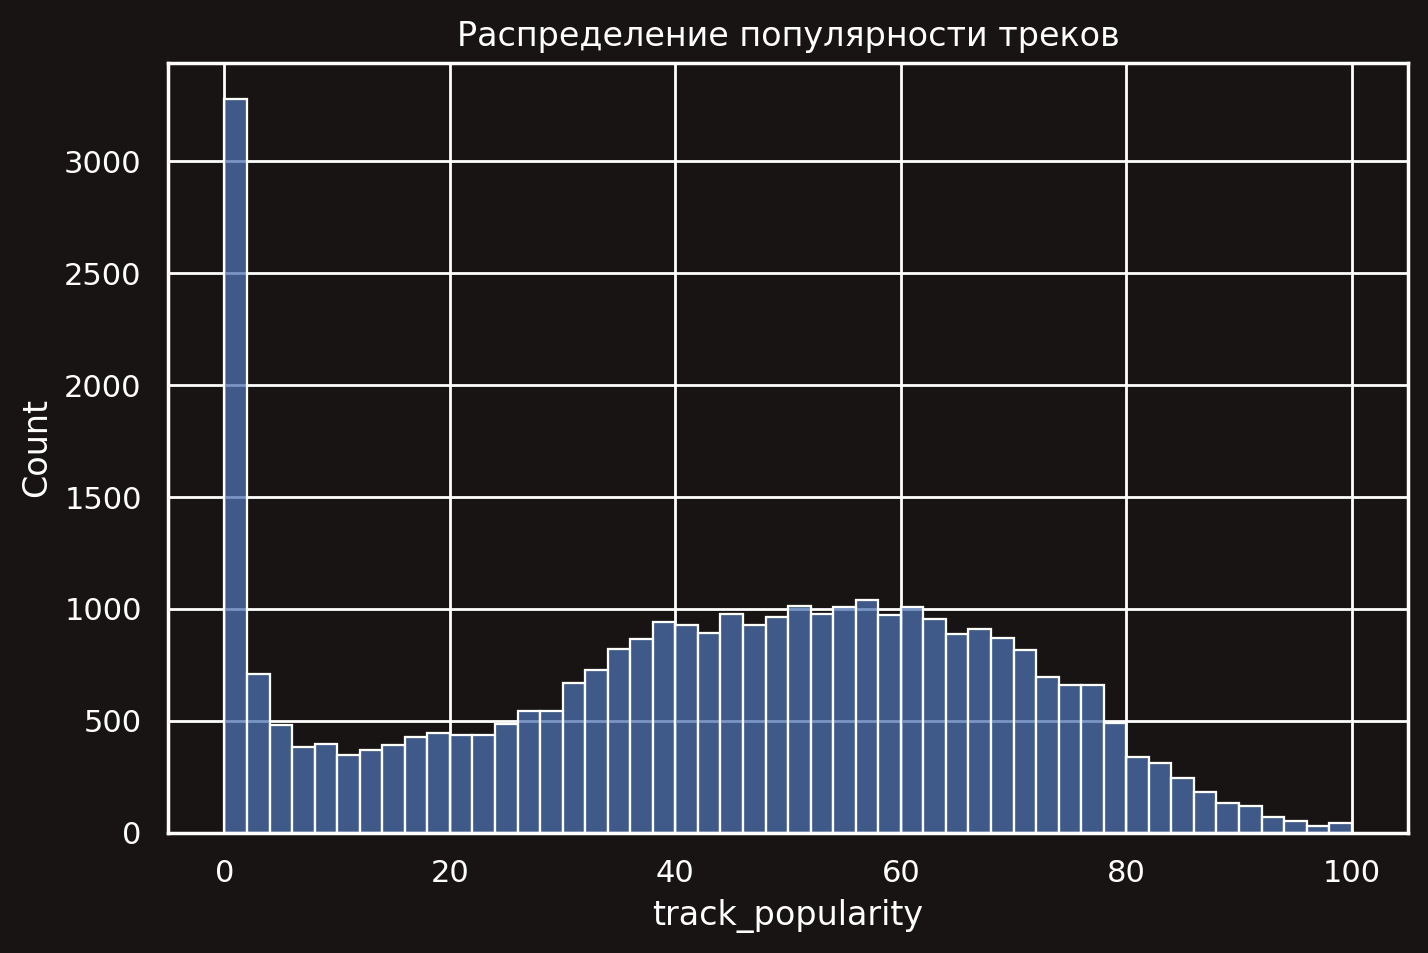

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(data['track_popularity'], bins=50)
plt.title('Распределение популярности треков')
plt.show()


Есть много треков с популярностью ровно 0. Скорее всего, это очень старые или удаленные треки, либо непопулярные нишевые жанры. Оставим их в данных, пусть модель учится предсказывать и такие провалы.

Выделим целевую переменную $y$ и матрицу признаков $X$. Мы удалим идентификаторы (ID, названия, исполнители), так как линейная модель работает только с признаками, которые можно осмысленно перевести в числа.


In [8]:
y = data['track_popularity']

# Удаляем таргет и текстовые идентификаторы
drop_cols = ['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date', 'track_popularity']
X = data.drop(columns=drop_cols)

Разобьем выборку на обучающую (train) и тестовую (test). Мы будем обучать модель на train, а проверять качество на test.


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)


Размер обучающей выборки: (26266, 16)
Размер тестовой выборки: (6567, 16)


Посмотрим на типы признаков.


In [10]:
X_train.dtypes


,0
playlist_name,object
playlist_id,object
playlist_genre,object
playlist_subgenre,object
danceability,float64
energy,float64
key,int64
loudness,float64
mode,int64
speechiness,float64


У нас есть числовые (float64, int64) и категориальные (object) признаки.


## Часть 2. Первая модель на числовых признаках
Линейная регрессия принимает на вход только числа. Давайте для начала выделим только числовые признаки и обучим модель на них.


In [11]:
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Числовые признаки:", numeric_features)

X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]


Числовые признаки: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


В `sklearn` есть несколько реализаций линейной регрессии. Самая базовая — `LinearRegression` (без регуляризации). Мы же будем использовать `Ridge` — линейную регрессию с $L_2$-регуляризацией, так как она более устойчива к мультиколлинеарности.


L2-регуляризация (Ridge, гребневая регуляция) — это метод в машинном обучении, который предотвращает переобучение модели, добавляя к функции потерь штраф, пропорциональный квадрату суммы весов.

In [12]:
from sklearn.linear_model import Ridge

# Создаем объект модели
model = Ridge()

# Обучаем модель (подбираем веса w и w0)
model.fit(X_train_num, y_train)


Ridge()

Модель обучилась! Теперь мы можем делать предсказания.


In [13]:
y_pred = model.predict(X_test_num)
y_pred[:5]


array([40.59181967, 32.72152833, 46.83138953, 39.98240993, 28.01202524])

Посчитаем качество. Основная метрика для задачи регрессии — **RMSE (Root Mean Squared Error)**.


In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE на тесте: {rmse:.2f}")

RMSE на тесте: 24.02


Ошибка в ~24 пункта популярности (по шкале от 0 до 100). Много это или мало? Для понимания нам нужен **бейзлайн** — простейшая модель. Например, если мы всегда будем предсказывать просто **среднюю** популярность всех треков из обучающей выборки.


In [15]:
y_pred_baseline = np.full_like(y_test, y_train.mean())
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
print(f"RMSE бейзлайна (просто среднее): {rmse_baseline:.2f}")


RMSE бейзлайна (просто среднее): 24.92


Наша модель (24.08) чуть лучше константы (24.96). Пока не очень впечатляет, но это только начало!


### Важность признаков и масштабирование
Давайте посмотрим на веса, которые выучила модель. Чем больше модуль веса, тем сильнее признак влияет на популярность.


In [16]:
weights = pd.Series(model.coef_, index=numeric_features)
weights.sort_values(ascending=False)


,0
danceability,5.199255
acousticness,3.576844
valence,2.553330
loudness,1.512851
mode,0.929778
tempo,0.020807
key,0.017742
duration_ms,-0.000046
liveness,-4.136095
speechiness,-7.410737


Кажется, что `instrumentalness` и `danceability` влияют сильнее всего, а `tempo` почти не влияет (вес близок к 0). **Но так делать нельзя!**

Признаки измеряются в разных шкалах: `duration_ms` измеряется в сотнях тысяч, а `danceability` от 0 до 1. Вес при `duration_ms` крошечный просто потому, что сам признак огромный.
Чтобы честно сравнивать веса, признаки нужно **отмасштабировать** (стандартизировать).


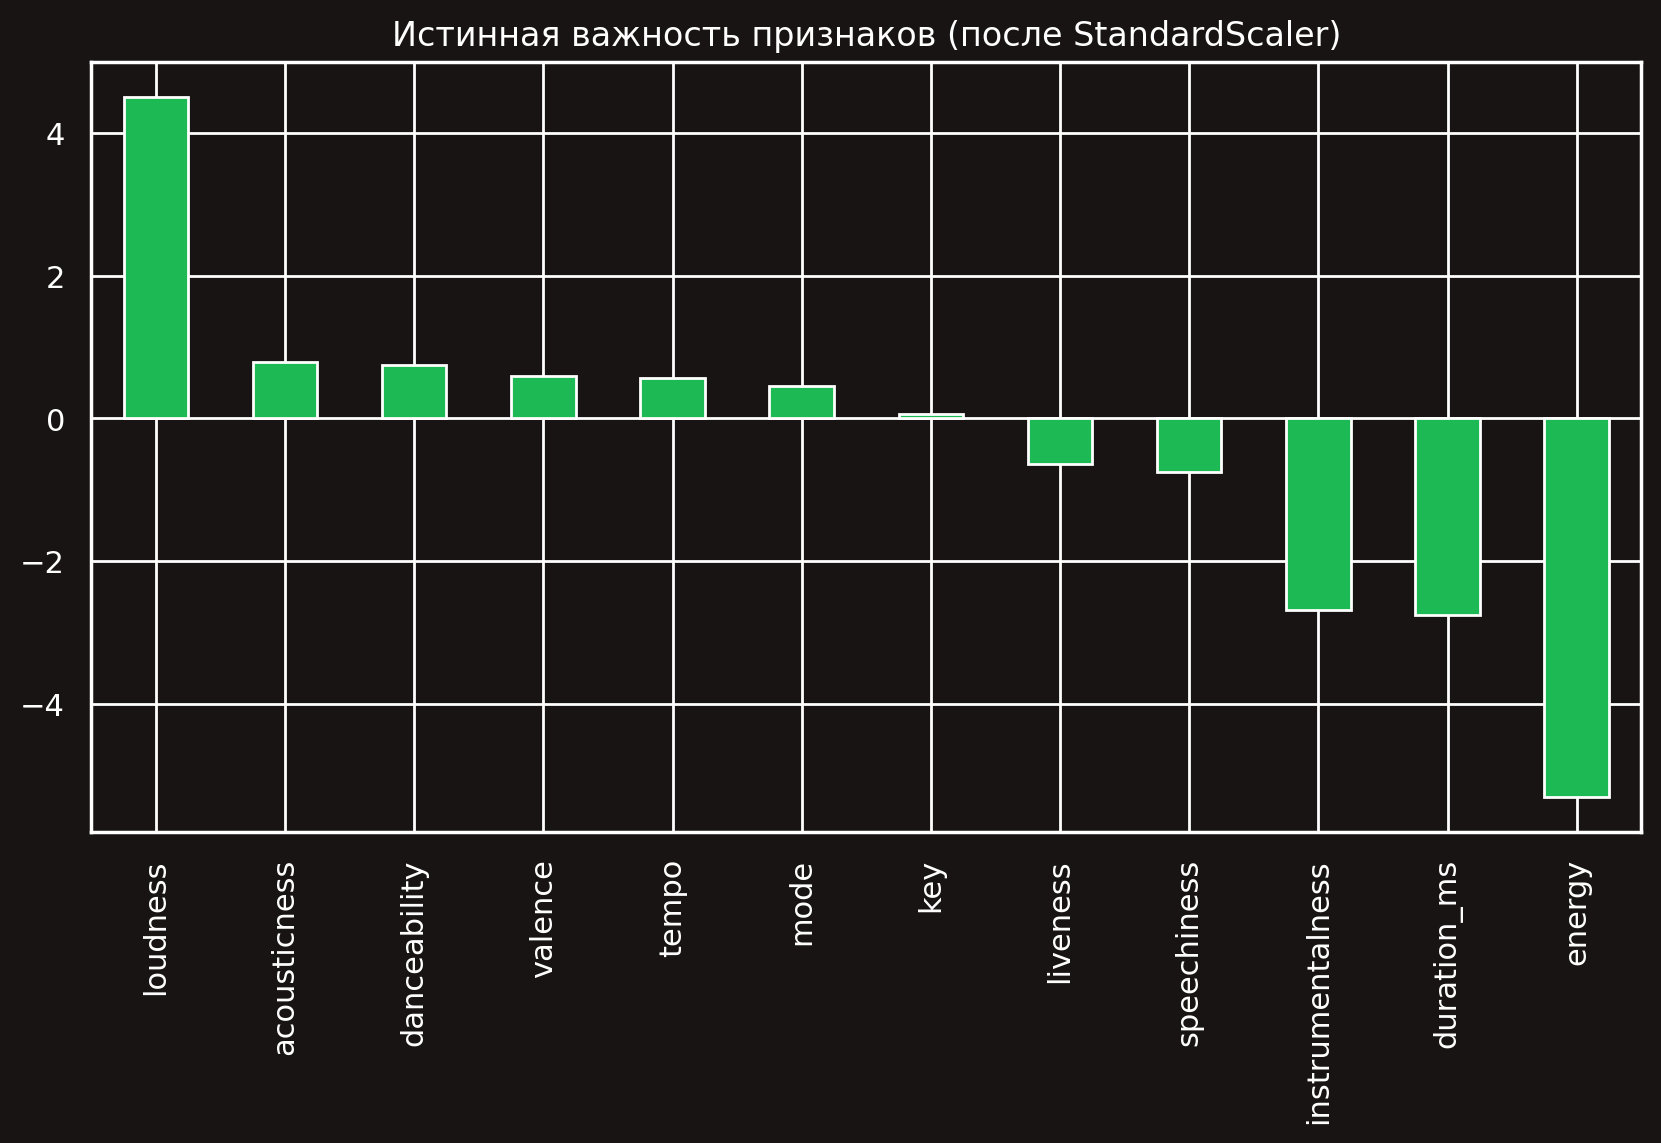

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Находим средние и дисперсии на train и сразу применяем к train
X_train_scaled = scaler.fit_transform(X_train_num)
# На test мы ТОЛЬКО применяем (не пересчитываем средние!)
X_test_scaled = scaler.transform(X_test_num)

# Обучаем новую модель на отмасштабированных данных
model_scaled = Ridge()
model_scaled.fit(X_train_scaled, y_train)

weights_scaled = pd.Series(model_scaled.coef_, index=numeric_features)
weights_scaled.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), color='#1DB954')
plt.title("Истинная важность признаков (после StandardScaler)")
plt.show()


Теперь картина совсем другая! Самый сильный положительный признак — это `danceability` (чем танцевальнее, тем популярнее), а самый сильный отрицательный — `instrumentalness` (люди в Spotify предпочитают песни с вокалом, а не чистые инструменталы).


### Подбор гиперпараметров (Кросс-валидация)
У модели `Ridge` есть гиперпараметр `alpha` — сила регуляризации. Подберем его оптимальное значение с помощью `GridSearchCV`.


In [19]:
from sklearn.model_selection import GridSearchCV

# Задаем сетку гиперпараметров
param_grid = {'alpha': np.logspace(-3, 3, 20)}

# cv=5 означает 5-фолдовую кросс-валидацию
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

print(f"Лучшее значение alpha: {grid_search.best_params_['alpha']}")
print(f"Лучший RMSE на кросс-валидации: {-grid_search.best_score_:.2f}")


Лучшее значение alpha: 54.555947811685144
Лучший RMSE на кросс-валидации: 24.09


## Часть 3. Категориальные признаки (Pipeline и ColumnTransformer)
Мы использовали только числа. А ведь у нас есть `playlist_genre` и `playlist_subgenre`. Линейная модель не понимает строк. Нам нужно применить **One-Hot Encoding**.

Чтобы не применять Scaler к одним колонкам руками, а OHE к другим, в `sklearn` есть `ColumnTransformer`.


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = ['playlist_genre', 'playlist_subgenre']

# Создаем трансформер: к числам применяем StandardScaler, к категориям — OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Собираем всё в Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=grid_search.best_params_['alpha']))
])


In [21]:
# Обучаем ВЕСЬ пайплайн одной строчкой!
pipeline.fit(X_train, y_train)

# Предсказываем
y_pred_pipe = pipeline.predict(X_test)
rmse_pipe = np.sqrt(mean_squared_error(y_test, y_pred_pipe))
print(f"RMSE с категориальными признаками: {rmse_pipe:.2f}")


RMSE с категориальными признаками: 22.99


Качество улучшилось с 24.08 до 23.36! Жанр песни действительно помогает предсказывать её популярность.


### Сравнение с Lasso-регрессией ($L_1$-регуляризация)
`Lasso` умеет делать отбор признаков, зануляя веса у бесполезных. После OneHotEncoding у нас стало очень много признаков (каждый поджанр стал отдельной колонкой). Посмотрим, сможет ли Lasso выкинуть лишнее.


In [22]:
from sklearn.linear_model import Lasso

pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.1)) # alpha=0.1 для Лассо обычно достаточно сильно режет
])

pipeline_lasso.fit(X_train, y_train)

# Считаем количество нулевых весов
zero_weights = np.sum(pipeline_lasso.named_steps['model'].coef_ == 0)
total_weights = len(pipeline_lasso.named_steps['model'].coef_)

print(f"Lasso занулил {zero_weights} признаков из {total_weights}!")
rmse_lasso = np.sqrt(mean_squared_error(y_test, pipeline_lasso.predict(X_test)))
print(f"RMSE Lasso: {rmse_lasso:.2f}")


Lasso занулил 12 признаков из 42!
RMSE Lasso: 23.09


## Часть 4. Анализ ошибок (Residuals)
Иногда полезно посмотреть, на каких примерах модель ошибается сильнее всего. Построим гистограмму квадратов ошибок.


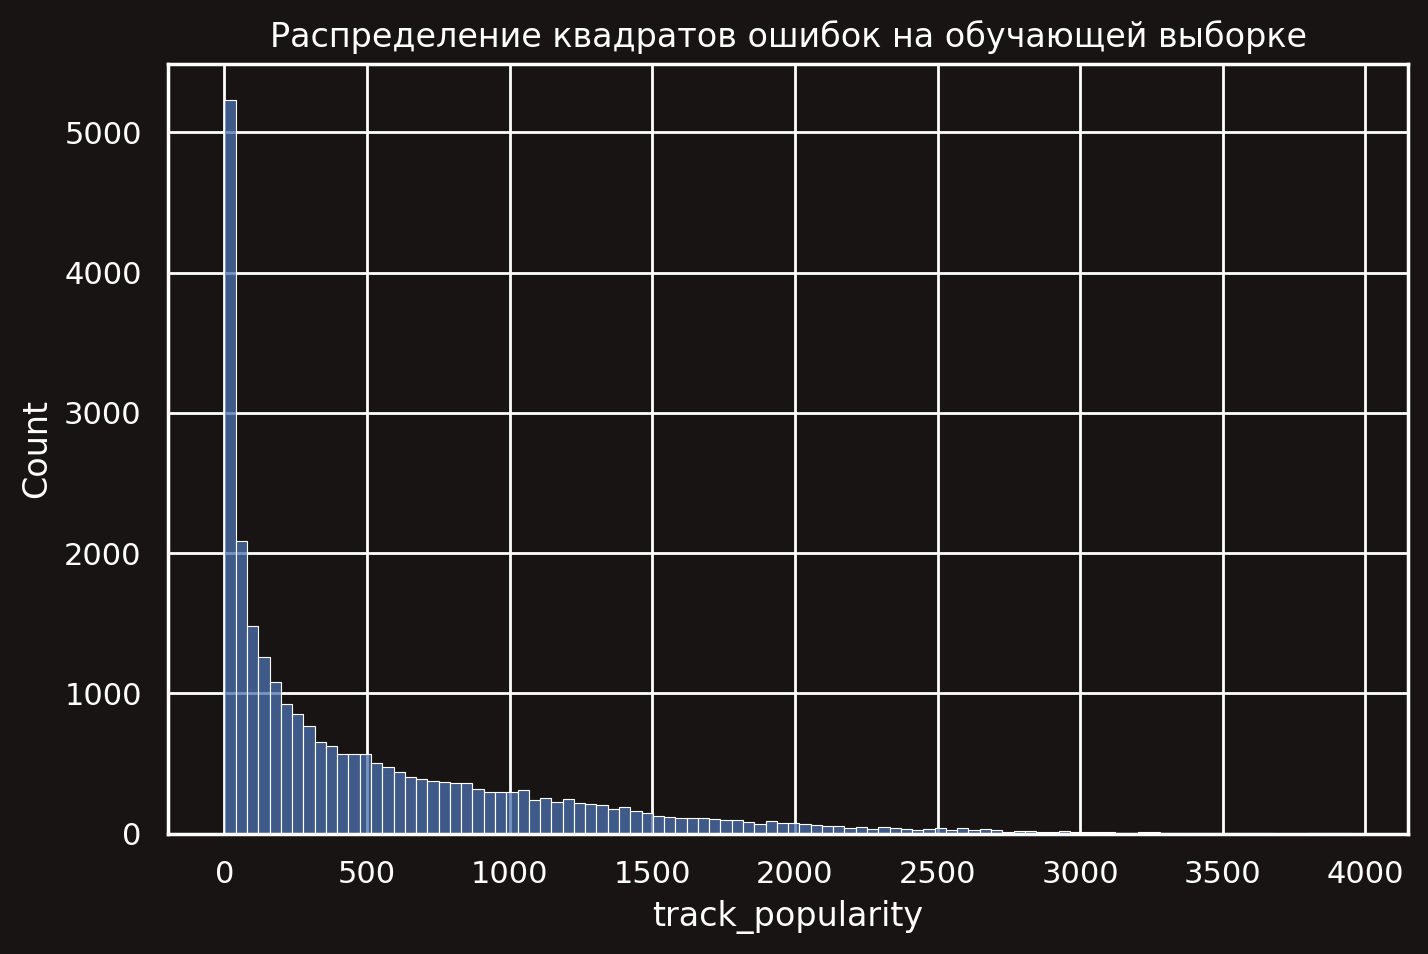

In [23]:
# Получаем предсказания на обучающей выборке
y_train_pred = pipeline.predict(X_train)
errors = (y_train - y_train_pred) ** 2

plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=100)
plt.title('Распределение квадратов ошибок на обучающей выборке')
plt.show()


У модели есть огромные ошибки (длинный хвост). Это "выбросы" — треки, чья популярность совершенно непредсказуема по аудио-фичам (например, старая песня внезапно завирусилась в TikTok).
Попробуем выкинуть топ-5% самых больших ошибок и переобучить модель.


In [24]:
# Берем 95-й квантиль ошибки
threshold = np.quantile(errors, 0.95)
mask = errors < threshold # Маска "хороших" треков

# Оставляем только те треки, где ошибка была не слишком большой
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

# Переобучаем
pipeline.fit(X_train_clean, y_train_clean)
y_pred_clean = pipeline.predict(X_test)
rmse_clean = np.sqrt(mean_squared_error(y_test, y_pred_clean))
print(f"RMSE после удаления выбросов: {rmse_clean:.2f}")


RMSE после удаления выбросов: 23.17


Качество на тестовой выборке улучшилось! Удаление шума из обучающей выборки часто помогает линейным моделям.
